# Term Project — LIN28A: Translation vs Stability separation

**Hypothesis.** Cho et al. 2012 conclude LIN28A acts as a *translational* suppressor of its bound mRNAs.  However, the paper does not quantitatively separate translation-mediated derepression (ΔTE) from stability-mediated derepression (ΔRNA) at the per-transcript level.  This project asks: for LIN28A-bound mRNAs, does derepression come from (a) ΔTE alone, (b) ΔRNA alone, (c) both — and do mRNA features (length, GC content, subcellular localization) distinguish the three mechanism groups?

**Plan.**
- **W4** — compute ΔRNA, ΔTE; define LIN28A bound genes by CLIP density; partition bound genes into mechanism groups.
- **W5** — compare mRNA features across groups with non-parametric tests + multiple-testing correction.
- **W6** — integrated figure; sanity-check with unbound controls; write-up.

## W4 — Data loading

Inputs (all from 1주차):
- `read-counts.txt` — featureCounts output, 6 BAMs: CLIP-35L33G, RNA-control, RNA-siLin28a, RNA-siLuc, RPF-siLin28a, RPF-siLuc.
- `mouselocalization.txt` — gene_id → subcellular localization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)

counts = pd.read_csv('read-counts.txt', sep='\t', skiprows=1)
counts.columns = [c.replace('.bam', '') for c in counts.columns]
print('shape:', counts.shape)
counts.head()

shape: (55359, 12)


,Geneid,Chr,Start,End,Strand,Length,CLIP-35L33G,RNA-control,RNA-siLin28a,RNA-siLuc,RPF-siLin28a,RPF-siLuc
0,ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0,0,0,0,0,0
1,ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0,0,0,0,0,0
2,ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4,1,1,1,0,0
3,ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3,0,0,0,0,0
4,ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0,0,0,0,0,0


In [ ]:
## W4-1 — Filtering, normalization, and key metrics

  - **Filter**: 4개 sample (RNA-siLuc, RNA-siLin28a, RPF-siLuc, RPF-siLin28a) 모두에서 count ≥ 10 인 유전자만 — 비표현 유전자에서 ratio가 noisy해지는 것 방지.
  - **CPM normalization**: 라이브러리 크기 차이 보정.
  - **ΔRNA** = log2(RNA_siLin28a / RNA_siLuc) — mRNA level 변화 (stability 대리지표).
  - **ΔTE** = log2((RPF/RNA)_siLin28a / (RPF/RNA)_siLuc) — 진짜 translational regulation.
  - **CLIP binding enrichment** = log2((CLIP_cpm + 1) / (RNA-siLuc_cpm + 1)) — mRNA 풍부도 보정한 LIN28A binding 강도. 단순 CLIP count는 긴 유전자/풍부한 유전자에 biased.

In [2]:
# Filter to expressed genes (count >= 10 in all 4 RNA/RPF samples)
keep = ((counts['RNA-siLuc']    >= 10) &
        (counts['RNA-siLin28a'] >= 10) &
        (counts['RPF-siLuc']    >= 10) &
        (counts['RPF-siLin28a'] >= 10))

sample_cols = ['RNA-siLuc', 'RNA-siLin28a', 'RPF-siLuc', 'RPF-siLin28a', 'CLIP-35L33G']
df = counts.loc[keep, ['Geneid', 'Length'] + sample_cols].copy()
df['Geneid'] = df['Geneid'].str.split('.').str[0]   # ENSMUSG... version 제거 (localization 매칭용)
print(f'expressed genes: {len(df)}')

# CPM normalization (use full table library size, not filtered)
libsize = counts[sample_cols].sum()
for c in sample_cols:
    df[c + '_cpm'] = df[c] / libsize[c] * 1e6

# ΔRNA: stability proxy
df['dRNA'] = np.log2(df['RNA-siLin28a_cpm'] / df['RNA-siLuc_cpm'])

# ΔTE: translational regulation
df['TE_siLuc']    = df['RPF-siLuc_cpm']    / df['RNA-siLuc_cpm']
df['TE_siLin28a'] = df['RPF-siLin28a_cpm'] / df['RNA-siLin28a_cpm']
df['dTE'] = np.log2(df['TE_siLin28a'] / df['TE_siLuc'])

# LIN28A binding enrichment per mRNA (controls for gene expression)
PSEUDO = 1
df['CLIP_enrichment'] = np.log2(
    (df['CLIP-35L33G_cpm'] + PSEUDO) / (df['RNA-siLuc_cpm'] + PSEUDO)
)

print(df[['dRNA', 'dTE', 'CLIP_enrichment']].describe().round(3))

expressed genes: 11596
            dRNA        dTE  CLIP_enrichment
count  11596.000  11596.000        11596.000
mean       0.056     -0.195           -0.543
std        0.472      0.660            1.065
min       -3.115     -2.836           -6.659
25%       -0.229     -0.649           -1.249
50%        0.026     -0.218           -0.596
75%        0.309      0.248            0.120
max        2.678      3.564            6.931


In [ ]:
## W4-2 — LIN28A bound vs unbound: ΔRNA × ΔTE 분포

  - ΔRNA, ΔTE를 median-center: ribosome profiling 표준. CPM이 글로벌 TE shift를 못 잡아주므로 "대부분 유전자는 변하지 않는다"는 가정 하에 median = 0으로 맞춤.
  우리 관심은 bound vs unbound *상대* 차이.
  - Bound 정의: CLIP_enrichment top quartile (Q3 이상).
  - Unbound 정의: bottom quartile (Q1 이하) — control.
  - Bound가 unbound 대비 (ΔRNA > 0) 또는 (ΔTE > 0) 방향으로 shift돼 있으면 derepression 증거.

binding
mid        5798
bound      2899
unbound    2899
Name: count, dtype: int64


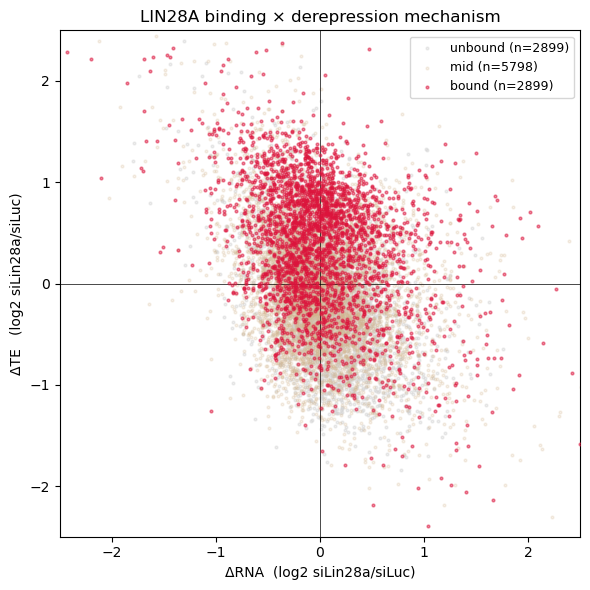

dRNA: bound > unbound,  U = 3641388,  p = 1.00e+00
dTE: bound > unbound,  U = 6498576,  p = 1.17e-284


In [3]:
# Median-center (global library shift 제거)
df['dRNA'] = df['dRNA'] - df['dRNA'].median()
df['dTE']  = df['dTE']  - df['dTE'].median()

# Bound = top quartile, Unbound = bottom quartile, 가운데는 'mid'
q1, q3 = df['CLIP_enrichment'].quantile([0.25, 0.75])
df['binding'] = np.where(df['CLIP_enrichment'] >= q3, 'bound',
                np.where(df['CLIP_enrichment'] <= q1, 'unbound', 'mid'))
print(df['binding'].value_counts())

# Scatter
fig, ax = plt.subplots(figsize=(6, 6))
for label, color, alpha, z in [('unbound', 'lightgrey', 0.4, 1),
                                ('mid',     'tan',       0.2, 2),
                                ('bound',   'crimson',   0.5, 3)]:
    sub = df[df['binding'] == label]
    ax.scatter(sub['dRNA'], sub['dTE'], s=4, alpha=alpha,
                color=color, label=f'{label} (n={len(sub)})', zorder=z)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('ΔRNA  (log2 siLin28a/siLuc)')
ax.set_ylabel('ΔTE   (log2 siLin28a/siLuc)')
ax.set_title('LIN28A binding × derepression mechanism')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()

# Mann-Whitney: bound > unbound? (one-sided)
from scipy.stats import mannwhitneyu
for col in ['dRNA', 'dTE']:
    u, p = mannwhitneyu(df.loc[df.binding=='bound', col],
                        df.loc[df.binding=='unbound', col],
                        alternative='greater')
    print(f'{col}: bound > unbound,  U = {u:.0f},  p = {p:.2e}')